# Fall Prevention in elderly people utilizing Deep Learning & Wearable Sensors.

In [ ]:
import datetime
script_begin_time = datetime.datetime.now()
print(script_begin_time)

2023-01-24 20:39:57.815173


# Dataset:




In [ ]:
# Dictionary for all "Activities of Dailiy Livings" & "Falls" (Total 36 classes)
task_dict={
    "T01":"Stand for 30 seconds (ADL)",
    "T02":"Stand, slowly bend the back with or without bending at knees, tie shoe lace, and get up (ADL)",
    "T03":"Pick up an object from the floor (ADL)",
    "T04":"Gently jump (try to reach an object) (ADL)",
    "T05":"Stand, sit to the ground, wait a moment, and get up with normal speed (ADL)",
    "T06":"Walk normally with turn (4m) (ADL)",
    "T07":"Walk quickly with turn (4m) (ADL)",
    "T08":"Jog normally with turn (4m) (ADL)",
    "T09":"Jog quickly with turn (4m) (ADL)",
    "T10":"Stumble while walking (ADL)",
    "T11":"Sit on a chair for 30 seconds (ADL)",
    "T12":"Sit on the sofa (back is inclined to the support) for 30 seconds (ADL)",
    "T13":"Sit down to a chair normally, and get up from a chair normally (ADL)",
    "T14":"Sit down to a chair quickly, and get up from a chair quickly (ADL)",
    "T15":"Sit a moment, trying to get up, and collapse into a chair (ADL)",
    "T16":"Stand, sit on the sofa (back is inclined to the support), and get up normally (ADL)",
    "T17":"Lie on the bed for 30 seconds (ADL)",
    "T18":"Sit a moment, lie down to the bed normally, and get up normally (ADL)",
    "T19":"Sit a moment, lie down to the bed quickly, and get up quickly (ADL)",
    "T20":"Forward fall when trying to sit down (FALL)",
    "T21":"Backward fall when trying to sit down (FALL)",
    "T22":"lateral fall when trying to sit down (FALL)",
    "T23" :"Forward fall when trying to get up (FALL)",
    "T24":"lateral fall when trying to get up (FALL)",
    "T25":"Forward fall while sitting, caused by fainting (FALL)",
    "T26":"lateral fall while sitting, caused by fainting (FALL)",
    "T27":"Backward fall while sitting, caused by fainting (FALL)",
    "T28":"Vertical(forward) fall while walking caused by fainting (FALL)",
    "T29":"Fall while walking, use of hands to dampen fall, caused by fainting (FALL)",
    "T30":"Forward fall while walking caused by a trip (FALL)",
    "T31":"Forward fall while jogging caused by a trip (FALL)",
    "T32":"Forward fall while walking caused by a slip (FALL)",
    "T33":"Lateral fall while walking caused by a slip (FALL)",
    "T34":"Backward fall while walking caused by a slip (FALL)",
    "T35":"Walk upstairs and downstairs normally (5 steps) (ADL)",
    "T36":"Walk upstairs and downstairs quickly (5 steps) (ADL)"
 }

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from keras.utils import np_utils

from sklearn import metrics
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
print('keras version ', keras.__version__)
# The number of steps within one time segment
TIME_PERIODS = 90
# The steps to take from one segment to the next; if this value is equal to
# TIME_PERIODS, then there is no overlap between the segments
STEP_DISTANCE = 6

keras version  2.8.0


In [ ]:
df = pd.read_csv ('/home2/samia.seecs/data/merged_data.csv')
df_ADL = df.groupby('Class_Label').get_group('ADL')
df_FALL = pd.read_csv ('/home2/samia.seecs/data/pre_impact_data.csv')
df_temp = df.groupby('Class_Label').get_group('FALL')

In [ ]:
frames = [df_ADL, df_FALL]
df = pd.concat(frames)

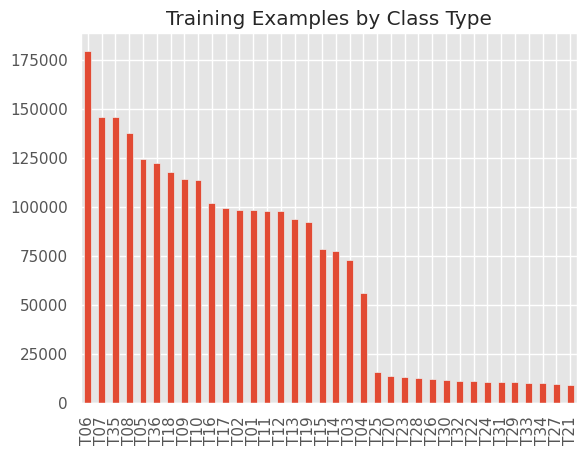

In [ ]:
# Show how many training examples exist for each of the six activities
df['Task ID'].value_counts().plot(kind='bar', title='Training Examples by Class Type')
plt.show()

In [ ]:
df['Task ID'].value_counts()


T06    179860
T07    146292
T35    145970
T08    137715
T05    124407
T36    122821
T18    117956
T09    114223
T10    113774
T16    101932
T17     99720
T02     98568
T01     98339
T11     98306
T12     98124
T13     93881
T19     92635
T15     78571
T14     77498
T03     72996
T04     56105
T25     15621
T20     13722
T23     13269
T28     12576
T26     12254
T30     11510
T32     11336
T22     11059
T24     10775
T31     10693
T29     10514
T33     10046
T34      9963
T27      9871
T21      9347
Name: Task ID, dtype: int64

In [ ]:
# Define column name of the label vector
LABEL = 'Class_Label_Encoded'
# Transform the labels from String to Integer via LabelEncoder
le = preprocessing.LabelEncoder()
# Add a new column to the existing DataFrame with the encoded values
df[LABEL] = le.fit_transform(df['Task ID'].values.ravel())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2442249 entries, 0 to 172555
Data columns (total 23 columns):
 #   Column               Dtype  
---  ------               -----  
 0   TimeStamp(s)         float64
 1   FrameCounter         int64  
 2   AccX                 float64
 3   AccY                 float64
 4   AccZ                 float64
 5   GyrX                 float64
 6   GyrY                 float64
 7   GyrZ                 float64
 8   EulerX               float64
 9   EulerY               float64
 10  EulerZ               float64
 11  Acc_Mag              float64
 12  Gyr_Mag              float64
 13  Euler_Mag            float64
 14  Class_Label          object 
 15  Ex_Label             int64  
 16  Task ID              object 
 17  Trial ID             object 
 18  Subject ID           object 
 19  diff_AccX            float64
 20  diff_AccY            float64
 21  diff_AccZ            float64
 22  Class_Label_Encoded  int64  
dtypes: float64(16), int64(3), object(

In [ ]:
#normalizing input variables for entire dataset
#ZScore Normalization
pd.options.mode.chained_assignment = None  # default='warn'
df['AccX'] = stats.zscore(df['AccX'])
df['AccY'] = stats.zscore(df['AccY'])
df['AccZ'] = stats.zscore(df['AccZ'])
df['GyrX'] = stats.zscore(df['GyrX'])
df['GyrY'] = stats.zscore(df['GyrY'])
df['GyrZ'] = stats.zscore(df['GyrZ'])
# Round numbers
df = df.round({'AccX': 4, 'AccY': 4, 'AccZ': 4,'GyrX': 4, 'GyrY': 4, 'GyrZ': 4})


In [ ]:
# Differentiate between test set and training set
def create_segments_and_labels(df, time_steps, step, label_name):
    # x, y, z acceleration & Gyroscope as features
    N_FEATURES = 6
    # Number of steps to advance in each iteration (for me, it should always
    # be equal to the time_steps in order to have no overlap between segments)
    # step = time_steps
    segments = []
    labels = []
    for i in range(0, len(df) - time_steps, step):
        AccX = df['AccX'].values[i: i + time_steps]
        AccY = df['AccY'].values[i: i + time_steps]
        AccZ = df['AccZ'].values[i: i + time_steps]
        GyrX = df['GyrX'].values[i: i + time_steps]
        GyrY = df['GyrY'].values[i: i + time_steps]
        GyrZ = df['GyrZ'].values[i: i + time_steps]
        # Retrieve the most often used label in this segment
        label = stats.mode(df[label_name][i: i + time_steps])[0][0]
        segments.append([AccX, AccY, AccZ, GyrX, GyrY, GyrZ])
        labels.append(label)

    # Bring the segments into a better shape
    reshaped_segments = np.asarray(segments, dtype= np.float32).reshape(-1, time_steps, N_FEATURES)
    labels = np.asarray(labels)

    return reshaped_segments, labels

x_data, y_data = create_segments_and_labels(df, TIME_PERIODS, STEP_DISTANCE, LABEL)

print (x_data.shape)
print(y_data.shape)

/tmp/ipykernel_614546/800355974.py:18: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  label = stats.mode(df[label_name][i: i + time_steps])[0][0]
/tmp/ipykernel_614546/800355974.py:18: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  label = stats.mode(df[label_name][i: i + time_steps])[0][0]


(407027, 90, 6)
(407027,)


In [ ]:
#deviding dataset into 80 % (train) and 20% test chuncks
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(325621, 90, 6) (325621,)
(81406, 90, 6) (81406,)


In [ ]:
# Set input & output dimensions
num_time_periods, num_sensors = X_train.shape[1], X_train.shape[2]
num_classes = le.classes_.size
labels=list(le.classes_)
print(list(le.classes_))

['T01', 'T02', 'T03', 'T04', 'T05', 'T06', 'T07', 'T08', 'T09', 'T10', 'T11', 'T12', 'T13', 'T14', 'T15', 'T16', 'T17', 'T18', 'T19', 'T20', 'T21', 'T22', 'T23', 'T24', 'T25', 'T26', 'T27', 'T28', 'T29', 'T30', 'T31', 'T32', 'T33', 'T34', 'T35', 'T36']


In [ ]:
print('X_train shape: ', X_train.shape)
print(X_train.shape[0], 'training samples')
y_train = np_utils.to_categorical(y_train, num_classes)
print('y_train shape: ', y_train.shape)

X_train shape:  (325621, 90, 6)
325621 training samples
y_train shape:  (325621, 36)


In [ ]:
print('X_test shape: ', X_test.shape)
print(X_test.shape[0], 'training samples')
y_test = np_utils.to_categorical(y_test, num_classes)
print('y_test shape: ', y_test.shape)

X_test shape:  (81406, 90, 6)
81406 training samples
y_test shape:  (81406, 36)


#Deep Leanring Model:

In [ ]:
###### Inception-Resent+BiGRU MODEL
from keras import models
from keras.layers import add
from matplotlib import pyplot
from keras.layers import Dense
from keras.models import Model
from keras.layers import Input
from keras.layers import Flatten

from keras.layers import Activation
from keras.models import Sequential
from keras.layers import Dropout,GRU
from keras.utils.vis_utils import plot_model
from keras.layers.convolutional import Conv1D
from keras.layers.convolutional import MaxPooling1D
from keras.layers import BatchNormalization,Bidirectional

In [ ]:
def create_model(trainX, trainy):
  n_timesteps, n_features, n_outputs = trainX.shape[1], trainX.shape[2], trainy.shape[1]
  input_shape=(n_timesteps,n_features)
  signal_input = Input(shape=input_shape, name='data')

#<---------------------------------------------module 1 starts---------------------------------------->
  
  layer_1_Just = Conv1D(filters=64,  kernel_size=1, padding='same', activation='relu')(signal_input) #with 1x1 conv
  
  layer_1_a = MaxPooling1D(pool_size=1, padding='same')(signal_input) # pooling
  layer_Max_a = Conv1D(64,  kernel_size=1, padding='same', activation='relu')(layer_1_a) # with 1x1  
  
  layer_1_a = Conv1D(filters=64,  kernel_size=1, padding='same', activation='relu')(signal_input) #with 1x1 conv
  layer_1_a = Conv1D(filters=64,  kernel_size=3, padding='same', activation='relu')(layer_1_a) # with 1x3 

  layer_2_a = Conv1D(64,  kernel_size=1, padding='same', activation='relu')(signal_input) #with 1x1
  layer_2_a = Conv1D(64,  kernel_size=5, padding='same', activation='relu')(layer_2_a)#with 1x5

  layer_3_a = Conv1D(64,  kernel_size=1, padding='same', activation='relu')(signal_input) #with 1x1
  layer_3_a = Conv1D(64,  kernel_size=7, padding='same', activation='relu')(layer_3_a) #with 1x7

  layer_4_a = Conv1D(64,  kernel_size=1, padding='same', activation='relu')(signal_input) #with 1x1
  layer_4_a = Conv1D(64,  kernel_size=9, padding='same', activation='relu')(layer_4_a) #with 1x9

  mid_1_a = keras.layers.concatenate([layer_Max_a,layer_1_Just,layer_1_a, layer_2_a,layer_3_a,layer_4_a], axis = 2)
  mid_1_a=Conv1D(filters=64,  kernel_size=1, padding='same', activation='relu')(mid_1_a) 

  input2SameDie=Conv1D(filters=64,  kernel_size=1, padding='same', activation='relu')(signal_input)
  after_addition1=add([mid_1_a,input2SameDie])
  drop0=Dropout(0.2)(after_addition1)
  bn1=BatchNormalization()(drop0)
#<----------------------------------------------module 1 ends here----------------------------->

#<----------------------------------------------module 2 starts---------------------------------------->
  
  layer_2_Just = Conv1D(filters=64,  kernel_size=1, padding='same', activation='relu')(bn1) #with 1x1 conv

  layer_2_a = MaxPooling1D(pool_size=1, padding='same')(bn1) # pooling
  layer_Max_a_2 = Conv1D(64,  kernel_size=1, padding='same', activation='relu')(layer_2_a) # with 1x1  

  layer_1_a = Conv1D(filters=64,  kernel_size=1, padding='same', activation='relu')(bn1) #with 1x1 conv
  layer_1_a = Conv1D(filters=64,  kernel_size=3, padding='same', activation='relu')(layer_1_a) # with 1x3 

  layer_2_a = Conv1D(64,  kernel_size=1, padding='same', activation='relu')(bn1) #with 1x1
  layer_2_a = Conv1D(64,  kernel_size=5, padding='same', activation='relu')(layer_2_a)#with 1x5

  layer_3_a = Conv1D(64,  kernel_size=1, padding='same', activation='relu')(bn1) #with 1x1
  layer_3_a = Conv1D(64,  kernel_size=7, padding='same', activation='relu')(layer_3_a) #with 1x7

  layer_4_a = Conv1D(64,  kernel_size=1, padding='same', activation='relu')(bn1) #with 1x1
  layer_4_a = Conv1D(64,  kernel_size=9, padding='same', activation='relu')(layer_4_a) #with 1x7

  mid_1_a = keras.layers.concatenate([layer_Max_a_2,layer_2_Just,layer_1_a, layer_2_a,layer_3_a,layer_4_a], axis = 2)
  mid_1_a=Conv1D(filters=64,  kernel_size=1, padding='same', activation='relu')(mid_1_a) 

  input2SameDie=Conv1D(filters=64,  kernel_size=1, padding='same', activation='relu')(bn1)
  after_addition2=add([mid_1_a,input2SameDie])
  drop1=Dropout(0.2)(after_addition2)
  bn2=BatchNormalization()(drop1)
#<----------------------------------------------module 2 ends here---------------------------------------->

  ShapeSameRawInput=Conv1D(filters=64,  kernel_size=1, padding='same', activation='relu')(signal_input) 
  FeaturesCon= keras.layers.concatenate([ShapeSameRawInput,bn2], axis = 2)

#-----------------------------------------Dense link----------------------------------------------------->

#<==//-//-//-//-//-//-//-//- CNN feature extraction Completed//-//-//-//-//-//-//-//-//-//==>

  rnn1=Bidirectional(GRU(128))(FeaturesCon) # GRU with 128 neurons
  bn2=BatchNormalization()(rnn1)

#<==//-//-//-//-//-//-//-//- RNN feature extraction Completed//-//-//-//-//-//-//-//-//-//==>

  flat_1 = Flatten()(bn2) # Flatting
  drop3=Dropout(0.2)(flat_1)

  dense_1 = Dense(512, activation='relu')(drop3)#Fully Connected
  drop4=Dropout(0.2)(dense_1)

  out = Dense(n_outputs, activation='softmax', name='predictions')(drop4) # Prediction
  
  rez = Model(inputs=signal_input, outputs=out)
  return rez

In [ ]:
model=create_model(X_train, y_train)

In [ ]:
inception= model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [ ]:
begin_time = datetime.datetime.now()
epochs, batch_size =200, 512 # here are the parameters of training verbose, epoch, batchSize
history=model.fit(X_train, y_train,validation_data=(X_test, y_test), epochs=epochs, batch_size=batch_size, verbose=1)
print(datetime.datetime.now() - begin_time)

Epoch 1/200


2023-01-24 20:41:39.690056: I tensorflow/stream_executor/cuda/cuda_dnn.cc:368] Loaded cuDNN version 8100
2023-01-24 20:41:40.932454: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-01-24 20:41:40.935087: W tensorflow/stream_executor/gpu/asm_compiler.cc:111] *** WARNING *** You are using ptxas 11.0.194, which is older than 11.1. ptxas before 11.1 is known to miscompile XLA code, leading to incorrect results or invalid-address errors.

You may not need to update to CUDA 11.1; cherry-picking the ptxas binary is often sufficient.


636/636 [==============================] - 86s 121ms/step - loss: 1.5138 - accuracy: 0.4666 - val_loss: 1.1192 - val_accuracy: 0.5859
Epoch 2/200
636/636 [==============================] - 78s 122ms/step - loss: 1.0247 - accuracy: 0.6220 - val_loss: 0.9183 - val_accuracy: 0.6618
Epoch 3/200
636/636 [==============================] - 78s 123ms/step - loss: 0.8890 - accuracy: 0.6716 - val_loss: 0.9064 - val_accuracy: 0.6664
Epoch 4/200
636/636 [==============================] - 75s 119ms/step - loss: 0.8033 - accuracy: 0.7014 - val_loss: 0.7283 - val_accuracy: 0.7314
Epoch 5/200
636/636 [==============================] - 75s 118ms/step - loss: 0.7391 - accuracy: 0.7265 - val_loss: 0.6960 - val_accuracy: 0.7369
Epoch 6/200
636/636 [==============================] - 75s 119ms/step - loss: 0.6861 - accuracy: 0.7460 - val_loss: 0.6385 - val_accuracy: 0.7654
Epoch 7/200
636/636 [==============================] - 75s 118ms/step - loss: 0.6428 - accuracy: 0.7621 - val_loss: 0.5873 - val_accurac

# Results

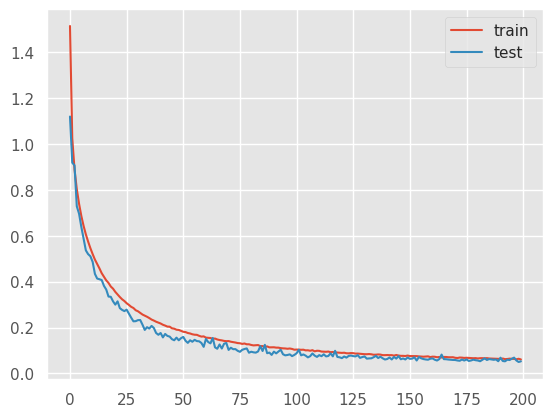

In [ ]:
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()

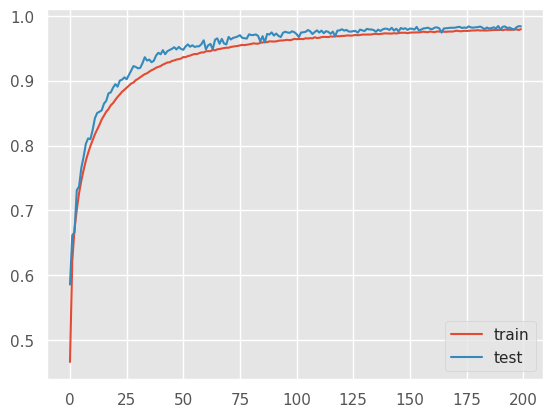

In [ ]:
pyplot.plot(history.history['accuracy'], label='train')
pyplot.plot(history.history['val_accuracy'], label='test')
pyplot.legend()
pyplot.show()

In [ ]:
_, accuracy = model.evaluate(X_test, y_test, batch_size=batch_size, verbose=0)
print ("Test accuracy = ",accuracy*100)

Test accuracy =  98.36252927780151


In [ ]:
_, accuracy = model.evaluate(X_train, y_train, batch_size=batch_size, verbose=0)
print ("Train accuracy = ",accuracy*100)

Train accuracy =  99.7662901878357


# Confusion Matrix

In [ ]:
labels= ['D01', 'D02', 'D03', 'D04', 'D05', 'D06', 'D07', 'D08', 'D09', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'D16', 'D17', 'D18', 'D19', 'F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'D20', 'D21']

In [ ]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
# create a confusion matrix to visually represent incorrectly classified classess
def plot_confusion_matrix(y_true, y_pred, classes, out_path=""):
    cm = confusion_matrix(y_true, y_pred,normalize="true")
    df_cm = pd.DataFrame(cm, index=[i for i in classes], columns=[i for i in classes])
    plt.figure(figsize=(22, 17))
    ax = sn.heatmap(df_cm, annot=True, square=True, cmap='Blues',  fmt=".2f")
    return ax

<AxesSubplot: >

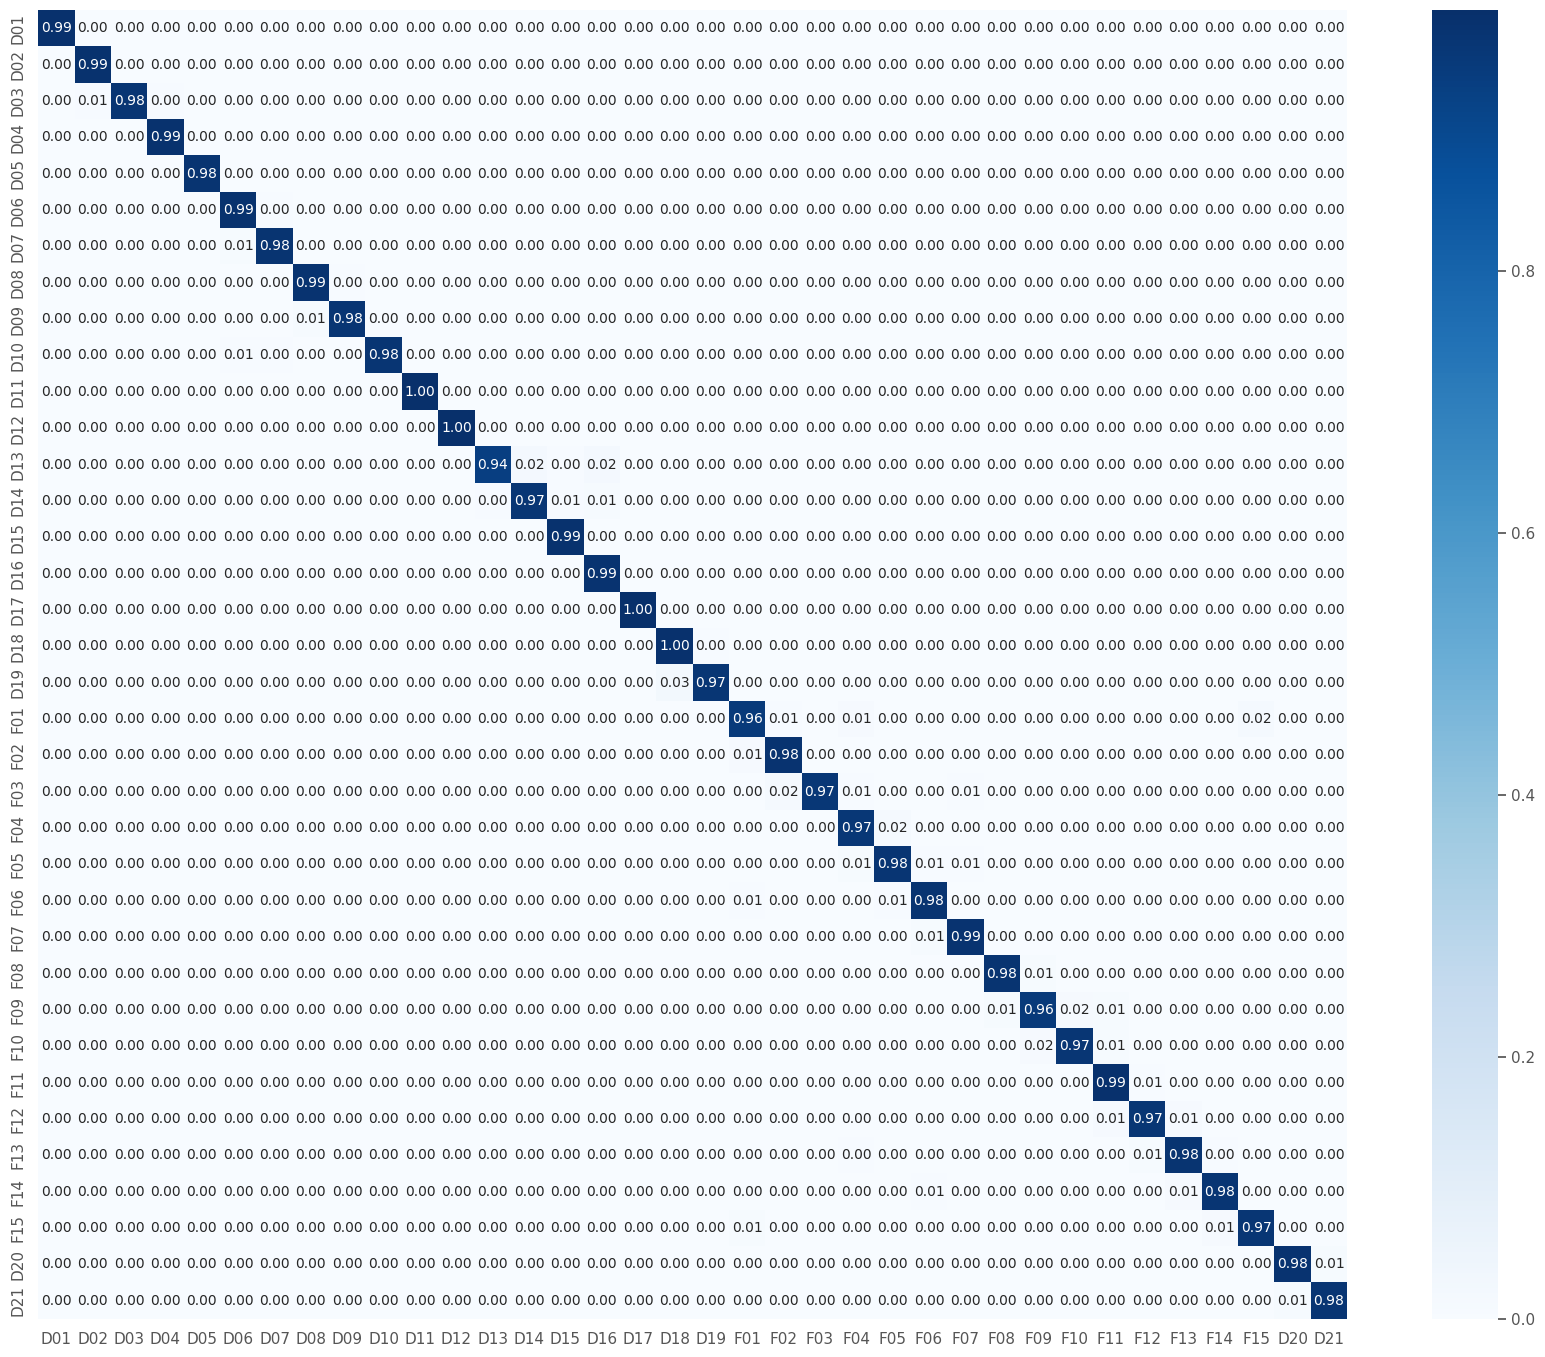

In [ ]:
y_pred=model.predict(X_test)
plot_confusion_matrix(y_test.argmax(axis=1),y_pred.argmax(axis=1),labels)

<AxesSubplot: >

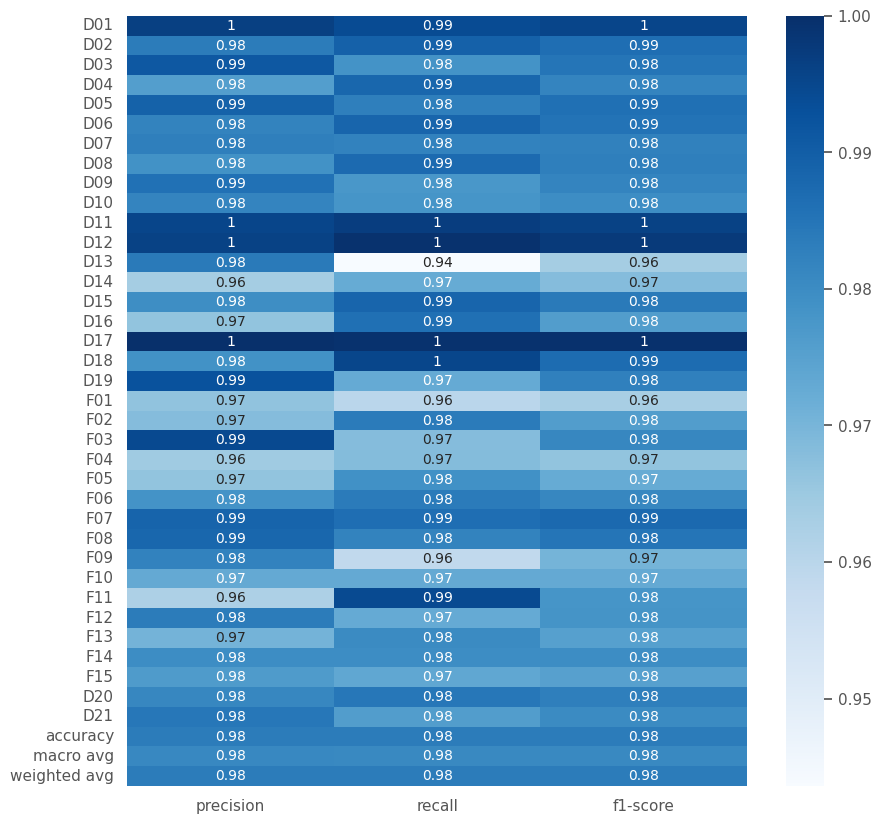

In [ ]:
from sklearn.metrics import classification_report
import seaborn as sns
y_pred=model.predict(X_test)
report= classification_report(y_test.argmax(axis=1),y_pred.argmax(axis=1),target_names=labels,output_dict=True)
fig, ax = plt.subplots(figsize=(10,10)) 
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap='Blues')

In [ ]:
model.save("/home2/samia.seecs/code/pre_impact_data/saved_models/fall_prevention_in_elderly.h5")

In [ ]:
script_end_time = datetime.datetime.now()
print(f'The script ran in {script_end_time - script_begin_time} hours.')

The script ran in 4:18:51.484119 hours.


In [ ]:
# task_dict={
#     "D01":"Stand for 30 seconds (ADL)",
#     "D02":"Stand, slowly bend the back with or without bending at knees, tie shoe lace, and get up (ADL)",
#     "D03":"Pick up an object from the floor (ADL)",
#     "D04":"Gently jump (try to reach an object) (ADL)",
#     "D05":"Stand, sit to the ground, wait a moment, and get up with normal speed (ADL)",
#     "D06":"Walk normally with turn (4m) (ADL)",
#     "D07":"Walk quickly with turn (4m) (ADL)",
#     "D08":"Jog normally with turn (4m) (ADL)",
#     "D09":"Jog quickly with turn (4m) (ADL)",
#     "D10":"Stumble while walking (ADL)",
#     "D11":"Sit on a chair for 30 seconds (ADL)",
#     "D12":"Sit on the sofa (back is inclined to the support) for 30 seconds (ADL)",
#     "D13":"Sit down to a chair normally, and get up from a chair normally (ADL)",
#     "D14":"Sit down to a chair quickly, and get up from a chair quickly (ADL)",
#     "D15":"Sit a moment, trying to get up, and collapse into a chair (ADL)",
#     "D16":"Stand, sit on the sofa (back is inclined to the support), and get up normally (ADL)",
#     "D17":"Lie on the bed for 30 seconds (ADL)",
#     "D18":"Sit a moment, lie down to the bed normally, and get up normally (ADL)",
#     "D19":"Sit a moment, lie down to the bed quickly, and get up quickly (ADL)",
#     "F01":"Forward fall when trying to sit down (FALL)",
#     "F02":"Backward fall when trying to sit down (FALL)",
#     "F03":"lateral fall when trying to sit down (FALL)",
#     "F04" :"Forward fall when trying to get up (FALL)",
#     "F05":"lateral fall when trying to get up (FALL)",
#     "F06":"Forward fall while sitting, caused by fainting (FALL)",
#     "F07":"lateral fall while sitting, caused by fainting (FALL)",
#     "F08":"Backward fall while sitting, caused by fainting (FALL)",
#     "F09":"Vertical(forward) fall while walking caused by fainting (FALL)",
#     "F10":"Fall while walking, use of hands to dampen fall, caused by fainting (FALL)",
#     "F11":"Forward fall while walking caused by a trip (FALL)",
#     "F12":"Forward fall while jogging caused by a trip (FALL)",
#     "F13":"Forward fall while walking caused by a slip (FALL)",
#     "F14":"Lateral fall while walking caused by a slip (FALL)",
#     "F15":"Backward fall while walking caused by a slip (FALL)",
#     "D20":"Walk upstairs and downstairs normally (5 steps) (ADL)",
#     "D21":"Walk upstairs and downstairs quickly (5 steps) (ADL)"
#  }